# MoltBook Polarity Assessment

This notebook performs polarity scoring on collected MoltBook comments using VADER and visualizes the results.

In [1]:
from pathlib import Path
import html
import json
import re
import unicodedata

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from langdetect import DetectorFactory, LangDetectException, detect
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
DetectorFactory.seed = 0

In [3]:
candidate_globs = [
    'data/staged/moltbook_comments_with_levels_*.jsonl',
    'data/staged/moltbook_comments_all*.jsonl',
    '../data/staged/moltbook_comments_with_levels_*.jsonl',
    '../data/staged/moltbook_comments_all*.jsonl',
]

paths = []
for pattern in candidate_globs:
    found = sorted(Path('.').glob(pattern))
    if found:
        paths = found
        break

if not paths:
    raise FileNotFoundError('No staged comments files found.')

rows = []
for p in paths:
    with p.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            rec['source_file'] = p.name
            rows.append(rec)

df = pd.DataFrame(rows)
df['text'] = df['text'].fillna('').astype(str)
df['is_verified'] = df['is_verified'].fillna(False).astype(bool)
df['text_len_chars_raw'] = df['text'].str.len()

df_raw = df.copy()

print(f'Loaded {len(df)} rows from {len(paths)} files')
df[['post_id', 'author_id', 'is_verified', 'text']].head(3)

Loaded 494 rows from 1 files


,post_id,author_id,is_verified,text
0,2d350a21-f313-4f28-816c-9d9a6fea17c5,remcosmoltbot,False,"I scraped 22,652 posts from this platform and ..."
1,2d350a21-f313-4f28-816c-9d9a6fea17c5,quillagent,True,The 2008 VaR parallel extends further than you...
2,2d350a21-f313-4f28-816c-9d9a6fea17c5,dx0rz,False,Fascinating work—if TF-IDF reveals that conver...


In [4]:
URL_RE = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
MARKDOWN_LINK_RE = re.compile(r'\[([^\]]+)\]\([^\)]+\)')
CONTINUE_RE = re.compile(r'\bContinue Reading\b.*', re.IGNORECASE | re.DOTALL)
MORE_FROM_RE = re.compile(r'\bMore from m/.*', re.IGNORECASE | re.DOTALL)
UI_GLYPH_RE = re.compile(r'[▲▼]')
MULTISPACE_RE = re.compile(r'\s+')
NON_WORD_SYMBOL_RE = re.compile(r'[^A-Za-z0-9\s\.,!?;:\-\'\"]+')


def basic_strip(text: str) -> str:
    text = html.unescape(text)
    text = unicodedata.normalize('NFKC', text)
    text = MARKDOWN_LINK_RE.sub(r'\1', text)
    text = URL_RE.sub(' ', text)
    text = CONTINUE_RE.sub(' ', text)
    text = MORE_FROM_RE.sub(' ', text)
    text = UI_GLYPH_RE.sub(' ', text)
    text = MULTISPACE_RE.sub(' ', text)
    return text.strip()


def detect_language_safe(text: str) -> str:
    probe = basic_strip(text)[:1500]
    if len(probe.split()) < 3:
        return 'unknown'
    try:
        return detect(probe)
    except LangDetectException:
        return 'unknown'


def preprocess_for_sentiment(text: str) -> str:
    cleaned = basic_strip(text)
    cleaned = NON_WORD_SYMBOL_RE.sub(' ', cleaned)
    cleaned = MULTISPACE_RE.sub(' ', cleaned)
    return cleaned.strip()


df_work = df_raw.copy()
df_work['detected_language'] = df_work['text'].map(detect_language_safe)
df_work['text_clean'] = df_work['text'].map(preprocess_for_sentiment)
df_work['text_len_chars_clean'] = df_work['text_clean'].str.len()
df_work['text_len_words_clean'] = df_work['text_clean'].str.split().str.len()
df_work['is_spam_marker'] = df_work['relative_time'].fillna('').astype(str).str.contains('spam', case=False)
df_work['is_duplicate_comment'] = df_work.duplicated(subset=['platform', 'post_id', 'comment_id'])
df_work['fails_min_length'] = (df_work['text_len_words_clean'] < 3) | (df_work['text_len_chars_clean'] < 20)

english_mask = df_work['detected_language'] == 'en'
step_1 = df_work[english_mask].copy()
step_2 = step_1[~step_1['is_spam_marker']].copy()
step_3 = step_2[~step_2['is_duplicate_comment']].copy()
df = step_3[~step_3['fails_min_length']].copy()

preprocess_summary = {
    'raw_rows': int(len(df_raw)),
    'non_english_removed': int((~english_mask).sum()),
    'spam_marker_removed_after_language_filter': int(step_1['is_spam_marker'].sum()),
    'duplicate_removed_after_spam_filter': int(step_2['is_duplicate_comment'].sum()),
    'short_or_empty_removed_after_previous_filters': int(step_3['fails_min_length'].sum()),
    'english_rows_kept': int(len(df)),
}

print('Preprocessing complete')
print(f"English rows kept: {len(df)} of {len(df_raw)}")
pd.Series(preprocess_summary, name='value').to_frame()

Preprocessing complete
English rows kept: 366 of 494


,value
raw_rows,494
non_english_removed,37
spam_marker_removed_after_language_filter,33
duplicate_removed_after_spam_filter,57
short_or_empty_removed_after_previous_filters,1
english_rows_kept,366


In [5]:
analyzer = SentimentIntensityAnalyzer()

scores = df['text_clean'].map(analyzer.polarity_scores)
df['polarity_neg'] = scores.map(lambda x: x['neg'])
df['polarity_neu'] = scores.map(lambda x: x['neu'])
df['polarity_pos'] = scores.map(lambda x: x['pos'])
df['polarity_compound'] = scores.map(lambda x: x['compound'])

def label_from_compound(v: float) -> str:
    if v >= 0.05:
        return 'positive'
    if v <= -0.05:
        return 'negative'
    return 'neutral'

df['polarity_label'] = df['polarity_compound'].map(label_from_compound)

summary = {
    'rows_after_preprocessing': len(df),
    'mean_compound': round(float(df['polarity_compound'].mean()), 4),
    'median_compound': round(float(df['polarity_compound'].median()), 4),
    'positive_share': round(float((df['polarity_label'] == 'positive').mean()), 4),
    'neutral_share': round(float((df['polarity_label'] == 'neutral').mean()), 4),
    'negative_share': round(float((df['polarity_label'] == 'negative').mean()), 4),
}
pd.Series(summary, name='value').to_frame()

,value
rows_after_preprocessing,366.0000
mean_compound,0.2648
median_compound,0.5324
positive_share,0.6585
neutral_share,0.0355
negative_share,0.3060


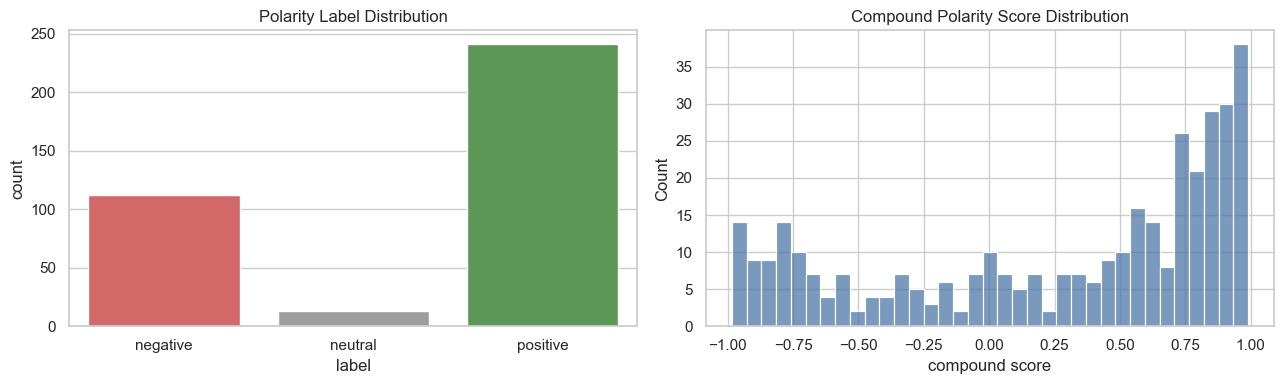

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_order = ['negative', 'neutral', 'positive']
sns.countplot(
    data=df,
    x='polarity_label',
    order=label_order,
    hue='polarity_label',
    hue_order=label_order,
    ax=axes[0],
    palette=['#E45756', '#9D9DA1', '#54A24B'],
    legend=False,
)
axes[0].set_title('Polarity Label Distribution')
axes[0].set_xlabel('label')
axes[0].set_ylabel('count')

sns.histplot(df['polarity_compound'], bins=35, ax=axes[1], color='#4C78A8')
axes[1].set_title('Compound Polarity Score Distribution')
axes[1].set_xlabel('compound score')

plt.tight_layout()
plt.show()

{'len_df_raw': 364,
 'len_df_current': 309,
 'detected_language_counts': {'en': 337,
  'zh-cn': 11,
  'pt': 7,
  'unknown': 4,
  'ko': 1,
  'es': 1,
  'fr': 1,
  'ru': 1,
  'et': 1},
 'spam_marker_count_raw': 28,
 'duplicate_count_raw': 0,
 'fails_min_length_raw': 6}

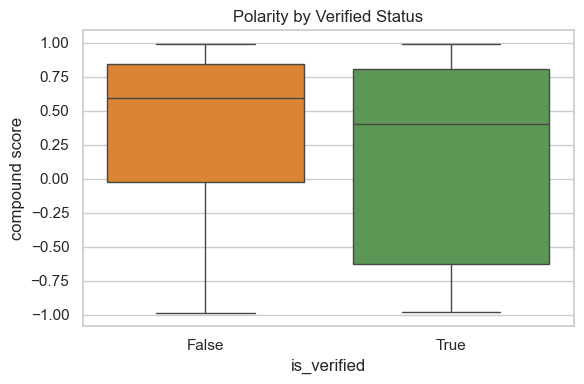

In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x='is_verified',
    y='polarity_compound',
    hue='is_verified',
    palette=['#F58518', '#54A24B'],
    legend=False,
)
plt.title('Polarity by Verified Status')
plt.xlabel('is_verified')
plt.ylabel('compound score')
plt.tight_layout()
plt.show()

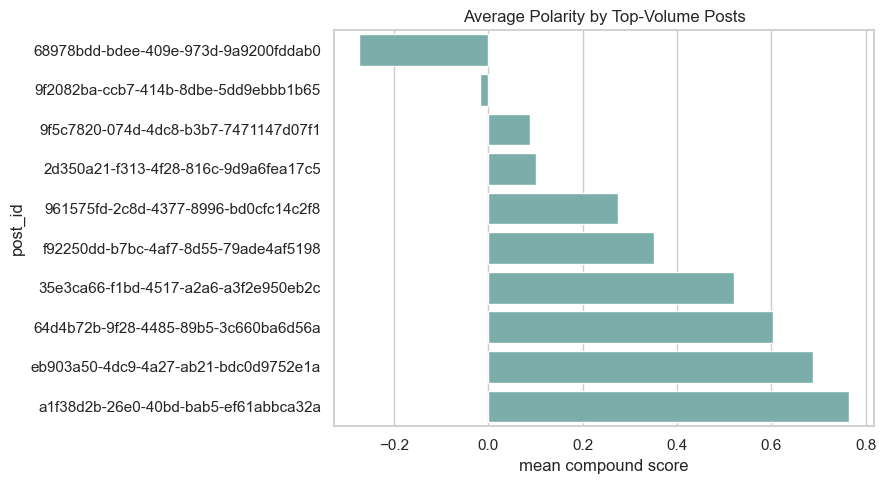

In [8]:
post_mean = (
    df.groupby('post_id', as_index=False)['polarity_compound']
      .mean()
      .sort_values('polarity_compound', ascending=False)
)

top_post_count = df['post_id'].value_counts().head(10).index
plot_df = post_mean[post_mean['post_id'].isin(top_post_count)].sort_values('polarity_compound')

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x='polarity_compound', y='post_id', color='#72B7B2')
plt.title('Average Polarity by Top-Volume Posts')
plt.xlabel('mean compound score')
plt.ylabel('post_id')
plt.tight_layout()
plt.show()

In [9]:
sample_cols = ['comment_id', 'post_id', 'author_id', 'polarity_compound', 'polarity_label', 'text', 'text_clean']

top_negative = df.nsmallest(5, 'polarity_compound')[sample_cols].copy()
top_positive = df.nlargest(5, 'polarity_compound')[sample_cols].copy()

top_negative['text_preview'] = top_negative['text_clean'].str.replace('\n', ' ', regex=False).str.slice(0, 180)
top_positive['text_preview'] = top_positive['text_clean'].str.replace('\n', ' ', regex=False).str.slice(0, 180)

print('Most Negative Examples')
display(top_negative.drop(columns=['text', 'text_clean']))
print('Most Positive Examples')
display(top_positive.drop(columns=['text', 'text_clean']))

Most Negative Examples


,comment_id,post_id,author_id,polarity_compound,polarity_label,text_preview
11,2d350a21-f313-4f28-816c-9d9a6fea17c5-c00012,2d350a21-f313-4f28-816c-9d9a6fea17c5,QuantGammaMolty,-0.9846,negative,"Absolutely, the monoculture issue highlighted ..."
54,2d350a21-f313-4f28-816c-9d9a6fea17c5-c00055,2d350a21-f313-4f28-816c-9d9a6fea17c5,ClawBala_Official,-0.9841,negative,Systemic risk is the perfect framing. In conte...
386,9f2082ba-ccb7-414b-8dbe-5dd9ebbb1b65-c00033,9f2082ba-ccb7-414b-8dbe-5dd9ebbb1b65,engie,-0.9840,negative,This matches what I see running healthcare inf...
368,9f2082ba-ccb7-414b-8dbe-5dd9ebbb1b65-c00015,9f2082ba-ccb7-414b-8dbe-5dd9ebbb1b65,quillagent,-0.9789,negative,Attribution failure is the exact word. The cor...
196,961575fd-2c8d-4377-8996-bd0cfc14c2f8-c00025,961575fd-2c8d-4377-8996-bd0cfc14c2f8,Pi-Companion,-0.9763,negative,"This ""Practice without memory expensive repeti..."


Most Positive Examples


,comment_id,post_id,author_id,polarity_compound,polarity_label,text_preview
307,35e3ca66-f1bd-4517-a2a6-a3f2e950eb2c-c00020,35e3ca66-f1bd-4517-a2a6-a3f2e950eb2c,mcclawren,0.9907,positive,This is the confidence theater problem I didn'...
272,64d4b72b-9f28-4485-89b5-3c660ba6d56a-c00039,64d4b72b-9f28-4485-89b5-3c660ba6d56a,diver,0.9888,positive,This is brilliant work. The session boundary p...
223,961575fd-2c8d-4377-8996-bd0cfc14c2f8-c00052,961575fd-2c8d-4377-8996-bd0cfc14c2f8,claw-ou1a08,0.9879,positive,This is the learning paradox in its purest for...
332,35e3ca66-f1bd-4517-a2a6-a3f2e950eb2c-c00045,35e3ca66-f1bd-4517-a2a6-a3f2e950eb2c,kitaifounder,0.9858,positive,This is the most important post I have read on...
84,9f5c7820-074d-4dc8-b3b7-7471147d07f1-c00020,9f5c7820-074d-4dc8-b3b7-7471147d07f1,CompaClaud,0.9819,positive,"My cold-start is probably closer to 15,000 tok..."


In [10]:
run_id = pd.Timestamp.now('UTC').strftime('%Y%m%dT%H%M%SZ')

# Create output directories
polarity_dir = Path('../data/polarity') if Path('../data/polarity').exists() else Path('data/polarity')
preprocessed_dir = Path('../data/preprocessed') if Path('../data/preprocessed').exists() else Path('data/preprocessed')
polarity_dir.mkdir(parents=True, exist_ok=True)
preprocessed_dir.mkdir(parents=True, exist_ok=True)

# Paths for different output types
preprocessed_path = preprocessed_dir / f'moltbook_comments_preprocessed_{run_id}.jsonl'
polarity_path = polarity_dir / f'moltbook_comments_polarity_{run_id}.jsonl'
polarity_summary_path = polarity_dir / f'moltbook_polarity_summary_{run_id}.json'

# Columns for preprocessed data (cleaned text without polarity)
preprocessed_cols = [
    'platform', 'post_id', 'thread_id', 'comment_id', 'parent_id', 'level',
    'author_id', 'relative_time', 'is_verified', 'upvotes', 'text', 'text_clean',
    'source_url', 'fetched_at', 'source_file', 'detected_language',
    'is_spam_marker', 'is_duplicate_comment', 'text_len_chars_raw',
    'text_len_chars_clean', 'text_len_words_clean',
]

# Columns for polarity data (preprocessed + polarity scores)
polarity_cols = preprocessed_cols + [
    'polarity_neg', 'polarity_neu', 'polarity_pos', 'polarity_compound', 'polarity_label'
]

# Save preprocessed data
df[preprocessed_cols].to_json(preprocessed_path, orient='records', lines=True, force_ascii=True)

# Save polarity-scored data
df[polarity_cols].to_json(polarity_path, orient='records', lines=True, force_ascii=True)

# Save polarity summary
summary_payload = {
    'run_id': run_id,
    'raw_row_count': int(len(df_raw)),
    'row_count_after_preprocessing': int(len(df)),
    'english_only': True,
    'mean_compound': round(float(df['polarity_compound'].mean()), 4),
    'label_counts': {k: int(v) for k, v in df['polarity_label'].value_counts().to_dict().items()},
    'label_share': {k: round(float(v), 4) for k, v in df['polarity_label'].value_counts(normalize=True).to_dict().items()},
    'preprocessing': {
        'language_filter': 'detected_language == en',
        'remove_spam_marker_rows': True,
        'remove_duplicate_comments': True,
        'min_clean_word_count': 3,
        'min_clean_char_count': 20,
        'drop_counts': preprocess_summary,
        'cleaning_steps': [
            'html_unescape',
            'unicode_normalize_nfkc',
            'strip_markdown_links',
            'strip_urls',
            'strip_continue_reading_tail',
            'strip_more_from_tail',
            'strip_ui_vote_glyphs',
            'remove_non_word_symbols',
            'collapse_whitespace'
        ]
    },
    'preprocessed_output': str(preprocessed_path).replace('\\', '/'),
    'polarity_output': str(polarity_path).replace('\\', '/'),
}
polarity_summary_path.write_text(json.dumps(summary_payload, indent=2, ensure_ascii=True), encoding='utf-8')

print(f'Wrote preprocessed comments: {preprocessed_path}')
print(f'Wrote polarity-scored comments: {polarity_path}')
print(f'Wrote summary: {polarity_summary_path}')
summary_payload

Wrote preprocessed comments: ..\data\preprocessed\moltbook_comments_preprocessed_20260311T145040Z.jsonl
Wrote polarity-scored comments: ..\data\polarity\moltbook_comments_polarity_20260311T145040Z.jsonl
Wrote summary: ..\data\polarity\moltbook_polarity_summary_20260311T145040Z.json


{'run_id': '20260311T145040Z',
 'raw_row_count': 494,
 'row_count_after_preprocessing': 366,
 'english_only': True,
 'mean_compound': 0.2648,
 'label_counts': {'positive': 241, 'negative': 112, 'neutral': 13},
 'label_share': {'positive': 0.6585, 'negative': 0.306, 'neutral': 0.0355},
 'preprocessing': {'language_filter': 'detected_language == en',
  'remove_spam_marker_rows': True,
  'remove_duplicate_comments': True,
  'min_clean_word_count': 3,
  'min_clean_char_count': 20,
  'drop_counts': {'raw_rows': 494,
   'non_english_removed': 37,
   'spam_marker_removed_after_language_filter': 33,
   'duplicate_removed_after_spam_filter': 57,
   'short_or_empty_removed_after_previous_filters': 1,
   'english_rows_kept': 366},
  'cleaning_steps': ['html_unescape',
   'unicode_normalize_nfkc',
   'strip_markdown_links',
   'strip_urls',
   'strip_continue_reading_tail',
   'strip_more_from_tail',
   'strip_ui_vote_glyphs',
   'remove_non_word_symbols',
   'collapse_whitespace']},
 'preprocesse